<p>Knowledge distillation is like a master chef (the Teacher) teaching an apprentice (the Student). Instead of the student just looking at the final dish (the Hard Label), the teacher explains the nuances of the ingredients and the subtle flavors (the Soft Targets).</p>

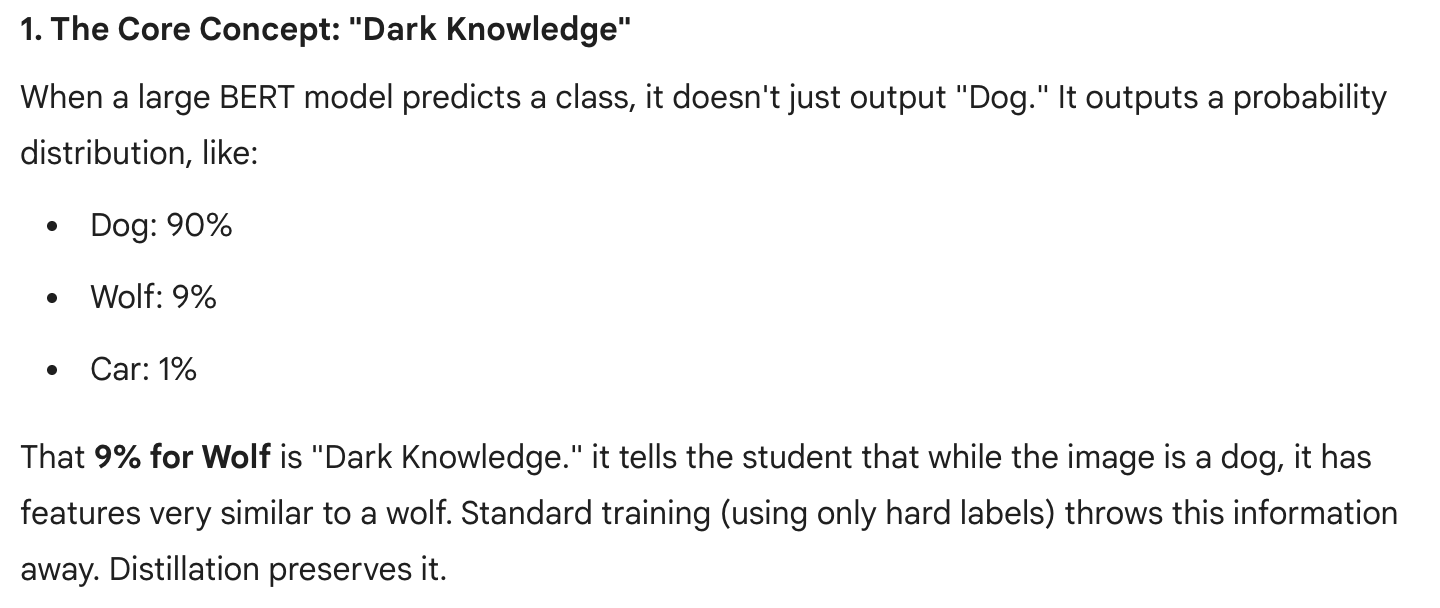

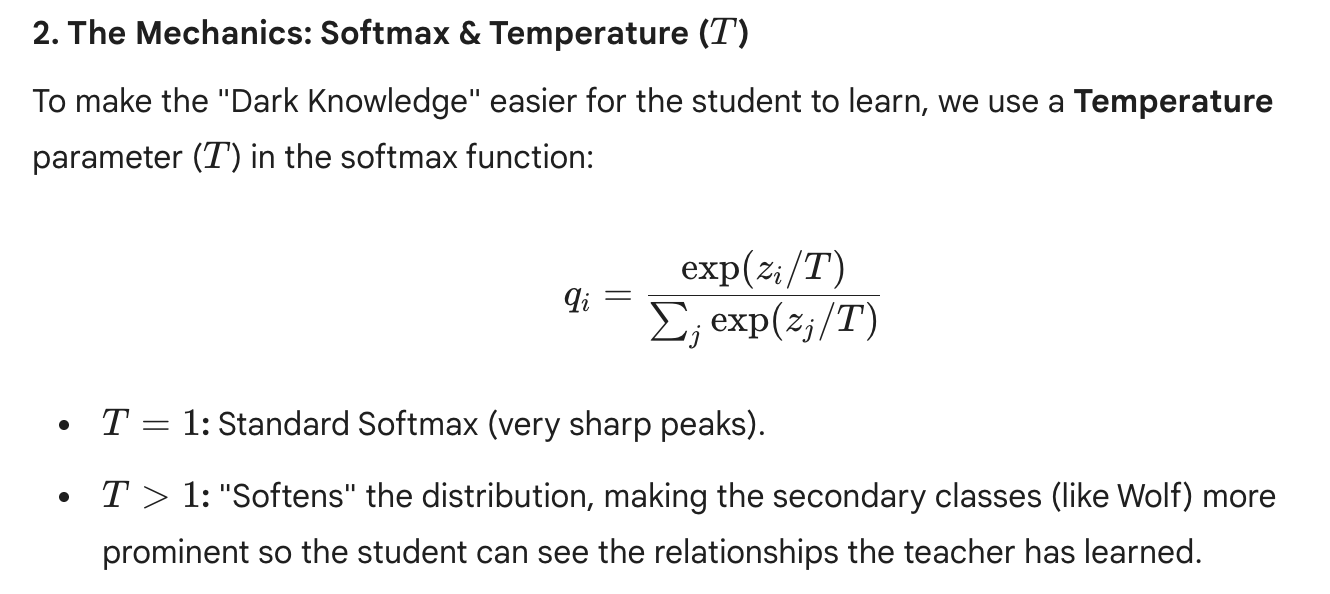

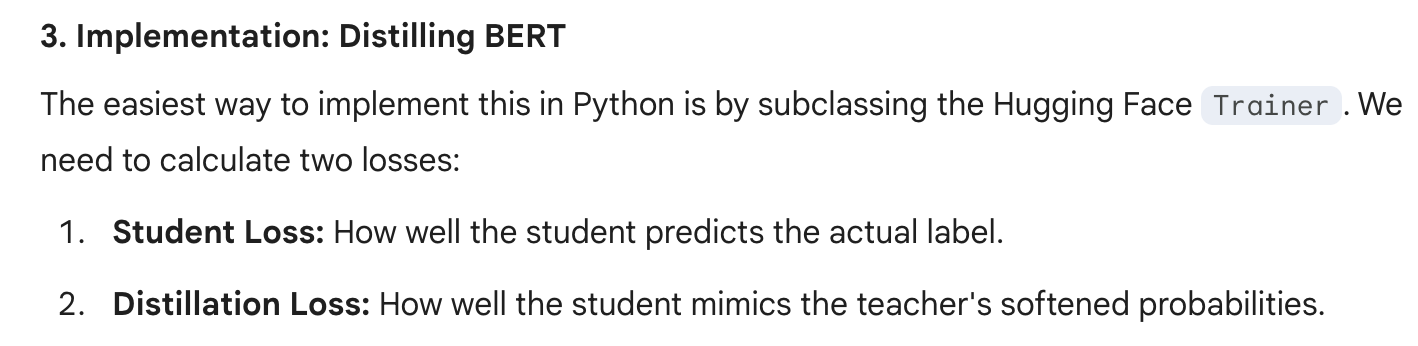

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import Trainer, TrainingArguments

class DistillationTrainer(Trainer):
    def __init__(self, *args, teacher_model=None, temperature=2.0, alpha=0.5, **kwargs):
        super().__init__(*args, **kwargs)
        self.teacher = teacher_model
        self.temperature = temperature
        self.alpha = alpha  # Balance between student loss and distillation loss

    def compute_loss(self, model, inputs, return_outputs=False):
        # 1. Student forward pass
        outputs_student = model(**inputs)
        student_loss = outputs_student.loss
        
        # 2. Teacher forward pass (no gradients needed)
        with torch.no_grad():
            outputs_teacher = self.teacher(**inputs)
        
        # 3. Compute Distillation Loss (KL Divergence)
        # We soften both distributions with the Temperature
        loss_function = nn.KLDivLoss(reduction="batchmean")
        
        distillation_loss = loss_function(
            F.log_softmax(outputs_student.logits / self.temperature, dim=-1),
            F.softmax(outputs_teacher.logits / self.temperature, dim=-1)
        ) * (self.temperature ** 2)
        
        # 4. Combined Loss
        loss = self.alpha * student_loss + (1. - self.alpha) * distillation_loss
        
        return (loss, outputs_student) if return_outputs else loss

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


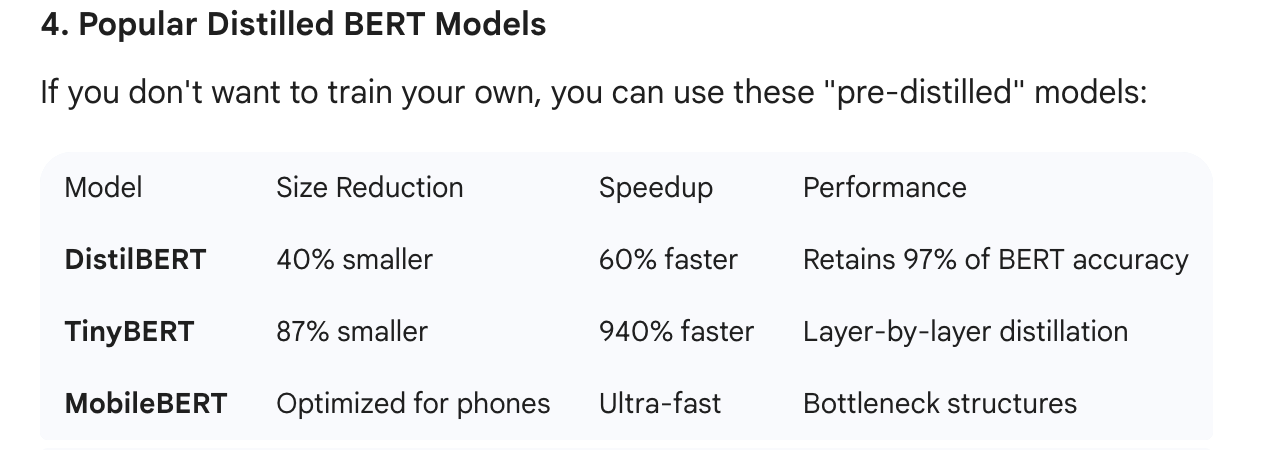